In [1]:
# import libraries
import cv2
import tifffile
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import os
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Ellipse
from scipy.spatial.transform import Rotation as R
import matplotlib.colors as mcolors

In [2]:
# velocity data
velocity_data_csv = r"./velocity_I15_entry_0013.nd2 - C=0-2_pair71_248_544.csv"
# given parameters
FPS = 1000/21
# relate pixel size to microns, 110 nm per pixel
pixel_size = 0.11

In [3]:
def plot_3D_polish_time(df, title, cmap=plt.cm.get_cmap('viridis'), continue_figure=False, show_track=True, track_alpha=1, tmin=0, tmax=80,  dot_alpha=0.5, dot_size=10, lin_width=1):
    norm = plt.Normalize(tmin, tmax)
    # plot 3D trajectory
    if continue_figure == False:
        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='3d'))  
    else:
        fig, ax = plt.gcf(), plt.gca()
    for i in range(len(df)):
        # color is based on frame
        color = cmap(norm(df.iloc[i]['frame']))
        ax.scatter(df.iloc[i]['x'], df.iloc[i]['y'], df.iloc[i]['z'], color=color, alpha=dot_alpha, s=dot_size)
    if show_track == True:
        for i in range(1, len(df)):
            # color is based on frame
            color = cmap(norm(df.iloc[i]['frame']))
            ax.plot(df.iloc[i-1:i+1]['x'], df.iloc[i-1:i+1]['y'], df.iloc[i-1:i+1]['z'], '-', alpha=track_alpha, color=color, linewidth=lin_width)
    # set title
    ax.set_title(title)
    # set axis
    ax.set_xlabel('x ($\mu$m)', fontsize=16)
    ax.set_ylabel('y ($\mu$m)', fontsize=16)
    ax.set_zlabel('z ($\mu$m)', fontsize=16)
    # tick font size
    ax.tick_params(axis='both', which='major', labelsize=14)
    return fig, ax

C:\Users\SSLabPowerfulJunior\AppData\Local\Temp\ipykernel_24508\1609835547.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  def plot_3D_polish_time(df, title, cmap=plt.cm.get_cmap('viridis'), continue_figure=False, show_track=True, track_alpha=1, tmin=0, tmax=80,  dot_alpha=0.5, dot_size=10, lin_width=1):


In [4]:
# load velocity data
velocity_data = pd.read_csv(velocity_data_csv)

In [5]:
# time color bar
cmap = plt.cm.summer
new_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap", cmap(np.linspace(0.1, 0.9, 256))  # Adjust range (0.9 removes yellow)
)

Text(0.5, 0, '')

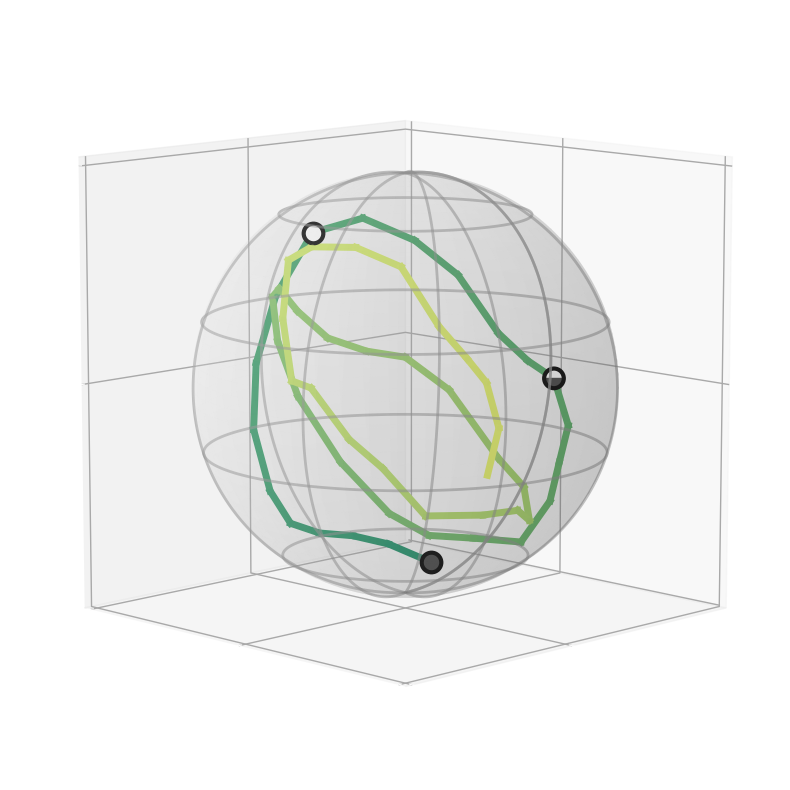

In [6]:
# bug-capsule 3D trajectory (polished version) # for elev = 10, azim = 45, roll = 0
capsule_radius = velocity_data.capsule_radius.max() + 0.2
t_min = 43
t_max = 95
lin_width = 5

cmap = new_cmap
# frame from 43 to 100
velocity_data_crop = velocity_data[(velocity_data.frame >= t_min) & (velocity_data.frame <= t_max)]
fig, ax = plot_3D_polish_time(velocity_data_crop, '', cmap=cmap, continue_figure=False, tmin=t_min, tmax=t_max, dot_size=10, lin_width=lin_width)
# set axis limit
lim = 4 

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)


# add 3D capsule as a sphere
origin = [0, 0, 0]
# draw sphere
# 500 points 
u, v = np.mgrid[0:2*np.pi:500j, 0:np.pi:250j]
x = capsule_radius * np.cos(u)*np.sin(v) + origin[0]
y = capsule_radius * np.sin(u)*np.sin(v) + origin[1]
z = capsule_radius * np.cos(v) + origin[2]
# fill sphere
ax.plot_surface(x, y, z, color='#E0E0E0', alpha=0.15)
# outline sphere
ax.plot_wireframe(x, y, z, color='#909090', alpha=0.55, linewidth=2, rstride=75, cstride=50, linestyle='-')

# add points, frame 44/53/59 
point_size = 200
white_point_color = '#FFFFFF'
dark_point_color = '#444444'
edge_color = 'k'
edge_thickness = 3
dark_frame = [44]
white_frame = [53]
semi_frame = [59]
# -1 for 0-based index
white_frame = [frame-1 for frame in white_frame]
dark_frame = [frame-1 for frame in dark_frame]
semi_frame = [frame-1 for frame in semi_frame]
from matplotlib.markers import MarkerStyle
for frame in white_frame:
    ax.scatter(velocity_data_crop[velocity_data_crop.frame == frame]['x'], velocity_data_crop[velocity_data_crop.frame == frame]['y'], velocity_data_crop[velocity_data_crop.frame == frame]['z'], color=white_point_color, alpha=1, s=point_size, edgecolor=edge_color, linewidth=edge_thickness)
for frame in dark_frame:
    ax.scatter(velocity_data_crop[velocity_data_crop.frame == frame]['x'], velocity_data_crop[velocity_data_crop.frame == frame]['y'], velocity_data_crop[velocity_data_crop.frame == frame]['z'], color=dark_point_color, alpha=1, s=point_size, edgecolor=edge_color, linewidth=edge_thickness)
for frame in semi_frame:
    # white point, top filled, no edge
    ax.scatter(velocity_data_crop[velocity_data_crop.frame == frame]['x'], velocity_data_crop[velocity_data_crop.frame == frame]['y'], velocity_data_crop[velocity_data_crop.frame == frame]['z'], color=white_point_color, alpha=1, s=point_size,  marker=MarkerStyle('o', fillstyle='top'))
    # dark point, bottom filled, no edge
    ax.scatter(velocity_data_crop[velocity_data_crop.frame == frame]['x'], velocity_data_crop[velocity_data_crop.frame == frame]['y'], velocity_data_crop[velocity_data_crop.frame == frame]['z'], color=dark_point_color, alpha=1, s=point_size, marker=MarkerStyle('o', fillstyle='bottom'))
    # hollow point with edge
    ax.scatter(velocity_data_crop[velocity_data_crop.frame == frame]['x'], velocity_data_crop[velocity_data_crop.frame == frame]['y'], velocity_data_crop[velocity_data_crop.frame == frame]['z'], color='none', alpha=1, s=point_size, edgecolor=edge_color, linewidth=edge_thickness)

# add arrow (add separately in illustrator)

# change view angle
ax.view_init(elev=10, azim=45, roll=0, vertical_axis='z') 
# reverse axis
ax.invert_xaxis()
ax.set_aspect('equal')

# change font size
large_font = 50
small_font = 30
ax.set_xlabel('x', fontsize=large_font, labelpad=15)
ax.set_ylabel('y', fontsize=large_font, labelpad=15)
ax.set_zlabel('z', fontsize=large_font, labelpad=5)
ax.tick_params(axis='both', which='major', labelsize=small_font, pad=5)
# thickness of axis
ax.xaxis._axinfo['grid'].update(color = '#A9A9A9', linestyle = '-', linewidth = 1)
ax.yaxis._axinfo['grid'].update(color = '#A9A9A9', linestyle = '-', linewidth = 1)
ax.zaxis._axinfo['grid'].update(color = '#A9A9A9', linestyle = '-', linewidth = 1)
# ax.grid(True, linestyle="-", linewidth=1.2, alpha=0.5)

# updates
ax.set_xticks([-4, 0])
ax.set_yticks([-4, 0, 4])
ax.set_zticks([0, 4])


# remove tick labels
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Hide x-axis line
ax.yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Hide y-axis line
ax.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Hide z-axis line
# grid: (3, -lim, -3) to (3, lim, -3)
shift_x = -0.3
shift_y = 0.4
ax.plot([4+shift_x, 4+shift_x], [-lim+shift_y, lim+shift_y], [-4, -4], color='#A9A9A9', alpha=1, linestyle="-", linewidth=1)
# tick colors to gray
# tick_color = '#A9A9A9'
tick_color = 'white'
ax.tick_params(axis='x', colors=tick_color)
ax.tick_params(axis='y', colors=tick_color)
ax.tick_params(axis='z', colors=tick_color)
# remove xyz labels
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_zlabel('')

# plt.tight_layout()
# save figure
# plt.savefig('3D view.png', format='png', dpi=900, transparent=True, bbox_inches='tight')



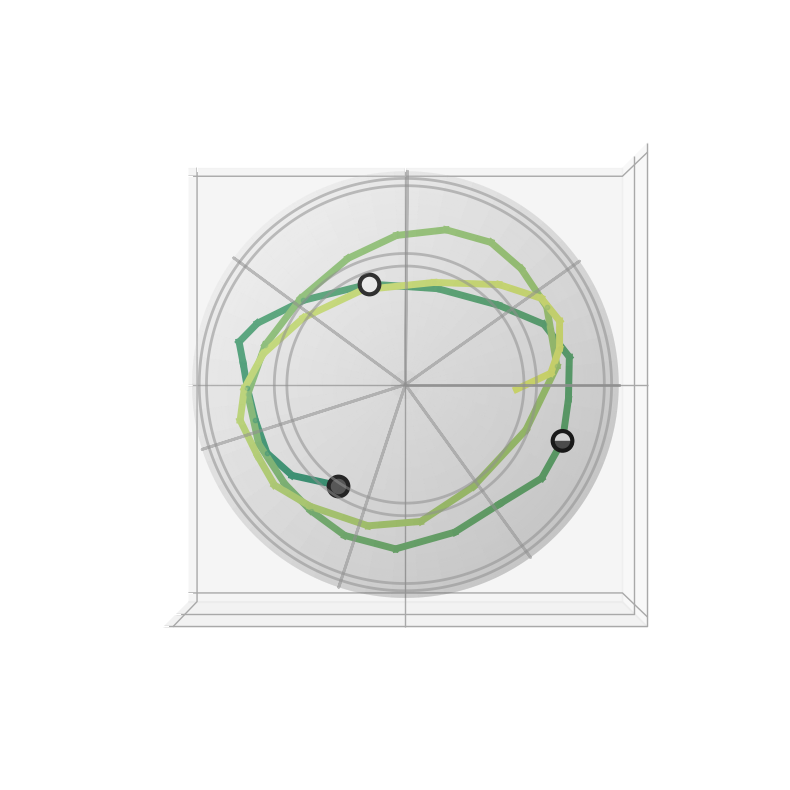

In [7]:
# bug-capsule 3D trajectory (polished version) # for xy projection: elev=90, azim=90, roll=0
capsule_radius = velocity_data.capsule_radius.max() + 0.2
t_min = 43
t_max = 95
lin_width = 5

cmap = new_cmap
# frame from 43 to 100
velocity_data_crop = velocity_data[(velocity_data.frame >= t_min) & (velocity_data.frame <= t_max)]
# velocity_data_crop = velocity_data.copy()
fig, ax = plot_3D_polish_time(velocity_data_crop, '', cmap=cmap, continue_figure=False, tmin=t_min, tmax=t_max, dot_size=10, lin_width=lin_width)
# set axis limit
lim = 4 

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)


# add 3D capsule as a sphere
origin = [0, 0, 0]
# draw sphere
# 500 points 
u, v = np.mgrid[0:2*np.pi:500j, 0:np.pi:250j]
x = capsule_radius * np.cos(u)*np.sin(v) + origin[0]
y = capsule_radius * np.sin(u)*np.sin(v) + origin[1]
z = capsule_radius * np.cos(v) + origin[2]
# fill sphere
ax.plot_surface(x, y, z, color='#E0E0E0', alpha=0.15)
# outline sphere
ax.plot_wireframe(x, y, z, color='#909090', alpha=0.55, linewidth=2, rstride=75, cstride=50, linestyle='-')

# add points, frame 44/53/59 
point_size = 200
white_point_color = '#FFFFFF'
dark_point_color = '#444444'
edge_color = 'k'
edge_thickness = 3
dark_frame = [44]
white_frame = [53]
semi_frame = [59]
# -1 for 0-based index
white_frame = [frame-1 for frame in white_frame]
dark_frame = [frame-1 for frame in dark_frame]
semi_frame = [frame-1 for frame in semi_frame]
from matplotlib.markers import MarkerStyle
for frame in white_frame:
    ax.scatter(velocity_data_crop[velocity_data_crop.frame == frame]['x'], velocity_data_crop[velocity_data_crop.frame == frame]['y'], velocity_data_crop[velocity_data_crop.frame == frame]['z'], color=white_point_color, alpha=1, s=point_size, edgecolor=edge_color, linewidth=edge_thickness)
for frame in dark_frame:
    ax.scatter(velocity_data_crop[velocity_data_crop.frame == frame]['x'], velocity_data_crop[velocity_data_crop.frame == frame]['y'], velocity_data_crop[velocity_data_crop.frame == frame]['z'], color=dark_point_color, alpha=1, s=point_size, edgecolor=edge_color, linewidth=edge_thickness)
for frame in semi_frame:
    # white point, top filled, no edge
    ax.scatter(velocity_data_crop[velocity_data_crop.frame == frame]['x'], velocity_data_crop[velocity_data_crop.frame == frame]['y'], velocity_data_crop[velocity_data_crop.frame == frame]['z'], color=white_point_color, alpha=1, s=point_size,  marker=MarkerStyle('o', fillstyle='top'))
    # dark point, bottom filled, no edge
    ax.scatter(velocity_data_crop[velocity_data_crop.frame == frame]['x'], velocity_data_crop[velocity_data_crop.frame == frame]['y'], velocity_data_crop[velocity_data_crop.frame == frame]['z'], color=dark_point_color, alpha=1, s=point_size, marker=MarkerStyle('o', fillstyle='bottom'))
    # hollow point with edge
    ax.scatter(velocity_data_crop[velocity_data_crop.frame == frame]['x'], velocity_data_crop[velocity_data_crop.frame == frame]['y'], velocity_data_crop[velocity_data_crop.frame == frame]['z'], color='none', alpha=1, s=point_size, edgecolor=edge_color, linewidth=edge_thickness)


# show xy projection (left y, bottom x)
ax.view_init(elev=90, azim=90, roll=0, vertical_axis='z')
# reverse axis
ax.invert_xaxis()
ax.set_aspect('equal')

# change font size
large_font = 50
small_font = 30
ax.set_xlabel('x', fontsize=large_font, labelpad=15)
ax.set_ylabel('y', fontsize=large_font, labelpad=15)
ax.set_zlabel('z', fontsize=large_font, labelpad=5)
ax.tick_params(axis='both', which='major', labelsize=small_font, pad=5)
# thickness of axis
ax.xaxis._axinfo['grid'].update(color = '#A9A9A9', linestyle = '-', linewidth = 1)
ax.yaxis._axinfo['grid'].update(color = '#A9A9A9', linestyle = '-', linewidth = 1)
ax.zaxis._axinfo['grid'].update(color = '#A9A9A9', linestyle = '-', linewidth = 1)

# updates
ax.set_xticks([-4, 0])
ax.set_yticks([-4, 0, 4])
ax.set_zticks([0, 4])


# remove tick labels
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Hide x-axis line
ax.yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Hide y-axis line
ax.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Hide z-axis line
# grid: (3, -lim, -3) to (3, lim, -3)
shift_x = -0.3
shift_y = 0.4
tick_color = 'white'
ax.tick_params(axis='x', colors=tick_color)
ax.tick_params(axis='y', colors=tick_color)
ax.tick_params(axis='z', colors=tick_color)
# remove xyz labels
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_zlabel('')

# shift xyz labels
ax.xaxis.labelpad = 40
ax.yaxis.labelpad = 40
ax.zaxis.labelpad = 20

# plt.tight_layout()
# save figure
# plt.savefig('xy view.png', format='png', dpi=900, transparent=True, bbox_inches='tight')

Text(0.5, 0, '')

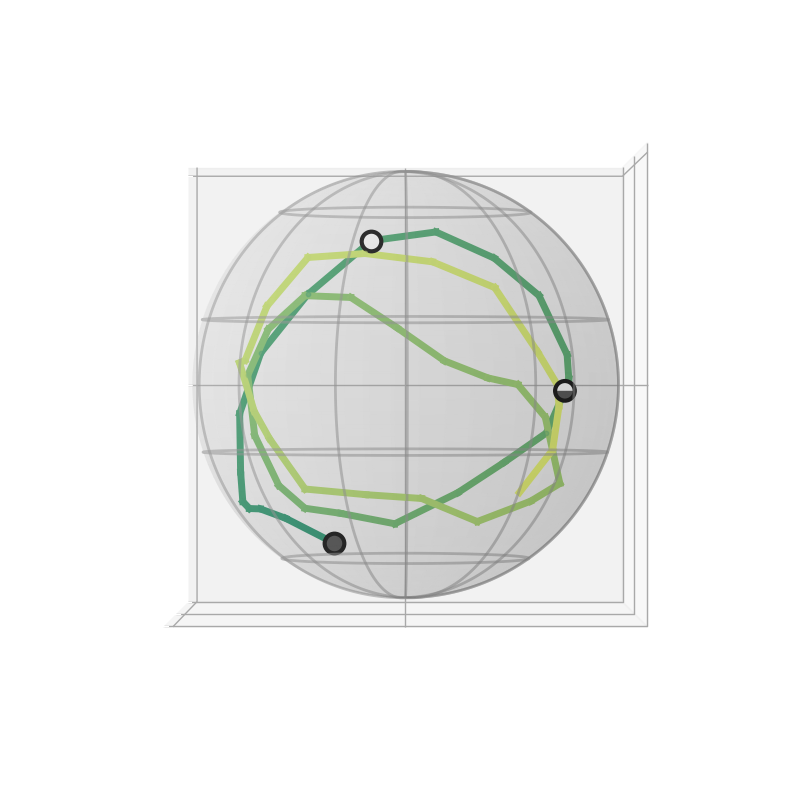

In [8]:
# bug-capsule 3D trajectory (polished version) # for xz projection: elev=90, azim=90, roll=0
capsule_radius = velocity_data.capsule_radius.max() + 0.2
t_min = 43
t_max = 95
lin_width = 5

cmap = new_cmap
# frame from 43 to 100
velocity_data_crop = velocity_data[(velocity_data.frame >= t_min) & (velocity_data.frame <= t_max)]
fig, ax = plot_3D_polish_time(velocity_data_crop, '', cmap=cmap, continue_figure=False, tmin=t_min, tmax=t_max, dot_size=10, lin_width=lin_width)
# set axis limit
lim = 4 

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)


# add 3D capsule as a sphere
origin = [0, 0, 0]
# draw sphere
# 500 points 
u, v = np.mgrid[0:2*np.pi:500j, 0:np.pi:250j]
x = capsule_radius * np.cos(u)*np.sin(v) + origin[0]
y = capsule_radius * np.sin(u)*np.sin(v) + origin[1]
z = capsule_radius * np.cos(v) + origin[2]
# fill sphere
ax.plot_surface(x, y, z, color='#E0E0E0', alpha=0.15)
# outline sphere
ax.plot_wireframe(x, y, z, color='#909090', alpha=0.55, linewidth=2, rstride=75, cstride=50, linestyle='-')

# add points, frame 44/53/59 
point_size = 200
white_point_color = '#FFFFFF'
dark_point_color = '#444444'
edge_color = 'k'
edge_thickness = 3
dark_frame = [44]
white_frame = [53]
semi_frame = [59]
# -1 for 0-based index
white_frame = [frame-1 for frame in white_frame]
dark_frame = [frame-1 for frame in dark_frame]
semi_frame = [frame-1 for frame in semi_frame]
from matplotlib.markers import MarkerStyle
for frame in white_frame:
    ax.scatter(velocity_data_crop[velocity_data_crop.frame == frame]['x'], velocity_data_crop[velocity_data_crop.frame == frame]['y'], velocity_data_crop[velocity_data_crop.frame == frame]['z'], color=white_point_color, alpha=1, s=point_size, edgecolor=edge_color, linewidth=edge_thickness)
for frame in dark_frame:
    ax.scatter(velocity_data_crop[velocity_data_crop.frame == frame]['x'], velocity_data_crop[velocity_data_crop.frame == frame]['y'], velocity_data_crop[velocity_data_crop.frame == frame]['z'], color=dark_point_color, alpha=1, s=point_size, edgecolor=edge_color, linewidth=edge_thickness)
for frame in semi_frame:
    # white point, top filled, no edge
    ax.scatter(velocity_data_crop[velocity_data_crop.frame == frame]['x'], velocity_data_crop[velocity_data_crop.frame == frame]['y'], velocity_data_crop[velocity_data_crop.frame == frame]['z'], color=white_point_color, alpha=1, s=point_size,  marker=MarkerStyle('o', fillstyle='top'))
    # dark point, bottom filled, no edge
    ax.scatter(velocity_data_crop[velocity_data_crop.frame == frame]['x'], velocity_data_crop[velocity_data_crop.frame == frame]['y'], velocity_data_crop[velocity_data_crop.frame == frame]['z'], color=dark_point_color, alpha=1, s=point_size, marker=MarkerStyle('o', fillstyle='bottom'))
    # hollow point with edge
    ax.scatter(velocity_data_crop[velocity_data_crop.frame == frame]['x'], velocity_data_crop[velocity_data_crop.frame == frame]['y'], velocity_data_crop[velocity_data_crop.frame == frame]['z'], color='none', alpha=1, s=point_size, edgecolor=edge_color, linewidth=edge_thickness)


# show xz projection (left z, bottom x)
ax.view_init(elev=0, azim=90, roll=0, vertical_axis='z')
# reverse axis
ax.invert_xaxis()
ax.set_aspect('equal')

# change font size
large_font = 50
small_font = 30
ax.set_xlabel('x', fontsize=large_font, labelpad=15)
ax.set_ylabel('y', fontsize=large_font, labelpad=15)
ax.set_zlabel('z', fontsize=large_font, labelpad=5)
ax.tick_params(axis='both', which='major', labelsize=small_font, pad=5)
# thickness of axis
ax.xaxis._axinfo['grid'].update(color = '#A9A9A9', linestyle = '-', linewidth = 1)
ax.yaxis._axinfo['grid'].update(color = '#A9A9A9', linestyle = '-', linewidth = 1)
ax.zaxis._axinfo['grid'].update(color = '#A9A9A9', linestyle = '-', linewidth = 1)
# ax.grid(True, linestyle="-", linewidth=1.2, alpha=0.5)

# updates
ax.set_xticks([-4, 0])
ax.set_yticks([-4, 0, 4])
ax.set_zticks([0, 4])


# remove tick labels
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Hide x-axis line
ax.yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Hide y-axis line
ax.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Hide z-axis line
shift_x = -0.3
shift_y = 0.4
tick_color = 'white'
ax.tick_params(axis='x', colors=tick_color)
ax.tick_params(axis='y', colors=tick_color)
ax.tick_params(axis='z', colors=tick_color)
# remove xyz labels
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_zlabel('')

# plt.tight_layout()
# save figure
# plt.savefig('xz view.png', format='png', dpi=900, transparent=True, bbox_inches='tight')
